# Week 8 Data Modelling Techniques and Machine Learning Algorithms Part 1
> by Lei Ding, Updated Apr. 2025

In [1]:
# 准备
#install.packages('class')
#install.packages('gmodels')
#install.packages('C50')
#install.packages('rpart')
#install.packages('rpart.plot')
#install.packages('ISLR')
#install.packages('tree')

## 1. K近邻算法

In [2]:
# import the CSV file
wbcd <- read.csv("wisc_bc_data.csv", stringsAsFactors = FALSE)
head(wbcd)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave.points_mean,⋯,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave.points_worst,symmetry_worst,fractal_dimension_worst
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,⋯,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
2,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,⋯,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
3,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,⋯,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
4,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,⋯,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
5,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,⋯,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
6,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,⋯,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [3]:
## Step 2: Exploring and preparing the data ---- 

# examine the structure of the wbcd data frame
str(wbcd)

'data.frame':	569 obs. of  32 variables:
 $ id                     : int  842302 842517 84300903 84348301 84358402 843786 844359 84458202 844981 84501001 ...
 $ diagnosis              : chr  "M" "M" "M" "M" ...
 $ radius_mean            : num  18 20.6 19.7 11.4 20.3 ...
 $ texture_mean           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ perimeter_mean         : num  122.8 132.9 130 77.6 135.1 ...
 $ area_mean              : num  1001 1326 1203 386 1297 ...
 $ smoothness_mean        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ compactness_mean       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ concavity_mean         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ concave.points_mean    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ symmetry_mean          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ fractal_dimension_mean : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius_se              : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture_se             : num  0.905 0.734 0.787 1

In [4]:
# drop the id feature
wbcd <- wbcd[-1]

# table of diagnosis
table(wbcd$diagnosis)


  B   M 
357 212 

In [5]:
# recode diagnosis as a factor
wbcd$diagnosis <- factor(wbcd$diagnosis, levels = c("B", "M"), labels = c("Benign", "Malignant"))

# table or proportions with more informative labels
round(prop.table(table(wbcd$diagnosis)) * 100, digits = 1)


   Benign Malignant 
     62.7      37.3 

In [6]:
# summarize three numeric features
summary(wbcd[c("radius_mean", "area_mean", "smoothness_mean")])

  radius_mean       area_mean      smoothness_mean  
 Min.   : 6.981   Min.   : 143.5   Min.   :0.05263  
 1st Qu.:11.700   1st Qu.: 420.3   1st Qu.:0.08637  
 Median :13.370   Median : 551.1   Median :0.09587  
 Mean   :14.127   Mean   : 654.9   Mean   :0.09636  
 3rd Qu.:15.780   3rd Qu.: 782.7   3rd Qu.:0.10530  
 Max.   :28.110   Max.   :2501.0   Max.   :0.16340  

In [7]:
# create normalization function
normalize <- function(x) {
  return ((x - min(x)) / (max(x) - min(x)))
}

# test normalization function - result should be identical
normalize(c(1, 2, 3, 4, 5))
normalize(c(10, 20, 30, 40, 50))

[1] 0.00 0.25 0.50 0.75 1.00

[1] 0.00 0.25 0.50 0.75 1.00

In [8]:
# normalize the wbcd data
wbcd_n <- as.data.frame(lapply(wbcd[2:31], normalize))

# confirm that normalization worked
summary(wbcd_n$area_mean)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.1174  0.1729  0.2169  0.2711  1.0000 

In [9]:
# create training and test data
wbcd_train <- wbcd_n[1:469, ]
wbcd_test <- wbcd_n[470:569, ]

# create labels for training and test data
wbcd_train_labels <- wbcd[1:469, 1]
wbcd_test_labels <- wbcd[470:569, 1]

In [10]:
## Step 3: Training a model on the data ----

# load the "class" library
library(class)

wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k = 21)

In [11]:
## Step 4: Evaluating model performance ----

# load the "gmodels" library
library(gmodels)

# Create the cross tabulation of predicted vs. actual
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq = FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        77 |         0 |        77 | 
                 |     1.000 |     0.000 |     0.770 | 
                 |     0.975 |     0.000 |           | 
                 |     0.770 |     0.000 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.025 |     1.000 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        79 |        21 |       100 | 
           

In [12]:
## Step 5: Improving model performance ----

# use the scale() function to z-score standardize a data frame
wbcd_z <- as.data.frame(scale(wbcd[-1]))

# confirm that the transformation was applied correctly
summary(wbcd_z$area_mean)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4532 -0.6666 -0.2949  0.0000  0.3632  5.2459 

In [13]:
# create training and test datasets
wbcd_train <- wbcd_z[1:469, ]
wbcd_test <- wbcd_z[470:569, ]

In [14]:
# re-classify test cases
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k = 21)

# Create the cross tabulation of predicted vs. actual
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq = FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        77 |         0 |        77 | 
                 |     1.000 |     0.000 |     0.770 | 
                 |     0.975 |     0.000 |           | 
                 |     0.770 |     0.000 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.025 |     1.000 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        79 |        21 |       100 | 
           

In [15]:
# try several different values of k

wbcd_train <- wbcd_n[1:469, ]
wbcd_test <- wbcd_n[470:569, ]

wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=1)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        72 |         5 |        77 | 
                 |     0.935 |     0.065 |     0.770 | 
                 |     0.973 |     0.192 |           | 
                 |     0.720 |     0.050 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.027 |     0.808 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        74 |        26 |       100 | 
           

In [16]:
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=5)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        74 |         3 |        77 | 
                 |     0.961 |     0.039 |     0.770 | 
                 |     1.000 |     0.115 |           | 
                 |     0.740 |     0.030 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         0 |        23 |        23 | 
                 |     0.000 |     1.000 |     0.230 | 
                 |     0.000 |     0.885 |           | 
                 |     0.000 |     0.230 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        74 |        26 |       100 | 
           

In [17]:
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=11)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        76 |         1 |        77 | 
                 |     0.987 |     0.013 |     0.770 | 
                 |     0.987 |     0.043 |           | 
                 |     0.760 |     0.010 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         1 |        22 |        23 | 
                 |     0.043 |     0.957 |     0.230 | 
                 |     0.013 |     0.957 |           | 
                 |     0.010 |     0.220 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        77 |        23 |       100 | 
           

In [18]:
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=15)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        77 |         0 |        77 | 
                 |     1.000 |     0.000 |     0.770 | 
                 |     0.975 |     0.000 |           | 
                 |     0.770 |     0.000 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.025 |     1.000 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        79 |        21 |       100 | 
           

In [19]:
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=21)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        77 |         0 |        77 | 
                 |     1.000 |     0.000 |     0.770 | 
                 |     0.975 |     0.000 |           | 
                 |     0.770 |     0.000 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.025 |     1.000 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        79 |        21 |       100 | 
           

In [20]:
wbcd_test_pred <- knn(train = wbcd_train, test = wbcd_test, cl = wbcd_train_labels, k=27)
CrossTable(x = wbcd_test_labels, y = wbcd_test_pred, prop.chisq=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  100 

 
                 | wbcd_test_pred 
wbcd_test_labels |    Benign | Malignant | Row Total | 
-----------------|-----------|-----------|-----------|
          Benign |        77 |         0 |        77 | 
                 |     1.000 |     0.000 |     0.770 | 
                 |     0.975 |     0.000 |           | 
                 |     0.770 |     0.000 |           | 
-----------------|-----------|-----------|-----------|
       Malignant |         2 |        21 |        23 | 
                 |     0.087 |     0.913 |     0.230 | 
                 |     0.025 |     1.000 |           | 
                 |     0.020 |     0.210 |           | 
-----------------|-----------|-----------|-----------|
    Column Total |        79 |        21 |       100 | 
           

# 2. 决策树算法

In [1]:
ID <- c(1:15)
age <- c(rep('young', 5), rep('middle', 5), rep('old', 5))
has_job <- c('false', 'false', 'true', 'true', 'false', 'false', 'false', 'true', 
             rep('false', 4), 'true', 'true', 'false')
own_house <- c(rep('false', 3), 'true', rep('false', 3), rep('true', 5), rep('false', 3))
credit_rating <- c('fair', 'good', 'good', rep('fair', 3), 'good', 'good', 
                   rep('excellent', 3), 'good', 'good', 'excellent', 'fair')
class <- c('No', 'No', 'Yes', 'Yes', rep('No', 3), rep('Yes', 7), 'No')

loan_data <- data.frame(age, has_job, own_house, credit_rating, class)
loan_data

age,has_job,own_house,credit_rating,class
<chr>,<chr>,<chr>,<chr>,<chr>
young,false,false,fair,No
young,false,false,good,No
young,true,false,good,Yes
young,true,true,fair,Yes
young,false,false,fair,No
middle,false,false,fair,No
middle,false,false,good,No
middle,true,true,good,Yes
middle,false,true,excellent,Yes


In [2]:
loan_data$class <- as.factor(loan_data$class)
str(loan_data)

'data.frame':	15 obs. of  5 variables:
 $ age          : chr  "young" "young" "young" "young" ...
 $ has_job      : chr  "false" "false" "true" "true" ...
 $ own_house    : chr  "false" "false" "false" "true" ...
 $ credit_rating: chr  "fair" "good" "good" "fair" ...
 $ class        : Factor w/ 2 levels "No","Yes": 1 1 2 2 1 1 1 2 2 2 ...


Warning message in partysplit(varid = as.integer(i), breaks = as.numeric(j[1]), :
“NAs introduced by coercion”
Warning message in partysplit(varid = as.integer(i), breaks = as.numeric(j[1]), :
“NAs introduced by coercion”
Warning message in .bincode(as.numeric(x), breaks = unique(c(-Inf, breaks_split(split), :
“NAs introduced by coercion”
Warning message in .bincode(as.numeric(x), breaks = unique(c(-Inf, breaks_split(split), :
“NAs introduced by coercion”


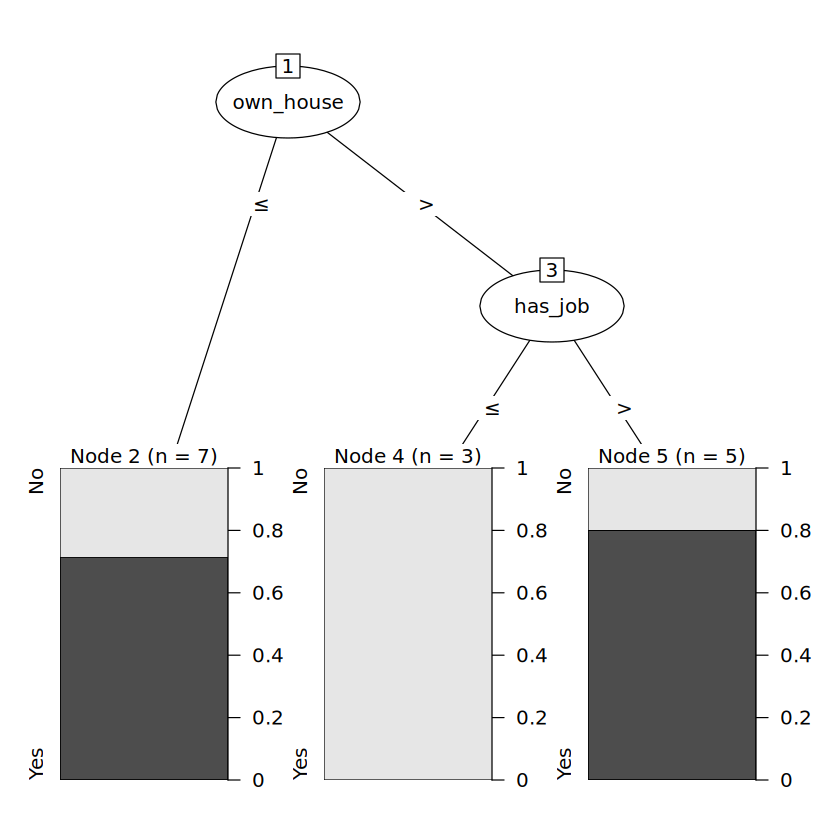

In [3]:
library(C50)
myTree <- C5.0(x=loan_data[, -5], y=loan_data$class)
plot(myTree)

In [5]:
summary(myTree)


Call:
C5.0.default(x = loan_data[, -5], y = loan_data$class)


C5.0 [Release 2.07 GPL Edition]  	Mon Apr  7 12:59:16 2025
-------------------------------

Class specified by attribute `outcome'

Read 15 cases (5 attributes) from undefined.data

Decision tree:

own_house = true: Yes (6)
own_house = false:
:...has_job = false: No (6)
    has_job = true: Yes (3)


Evaluation on training data (15 cases):

	    Decision Tree   
	  ----------------  
	  Size      Errors  

	     3    0( 0.0%)   <<


	   (a)   (b)    <-classified as
	  ----  ----
	     6          (a): class No
	           9    (b): class Yes


	Attribute usage:

	100.00%	own_house
	 60.00%	has_job


Time: 0.0 secs


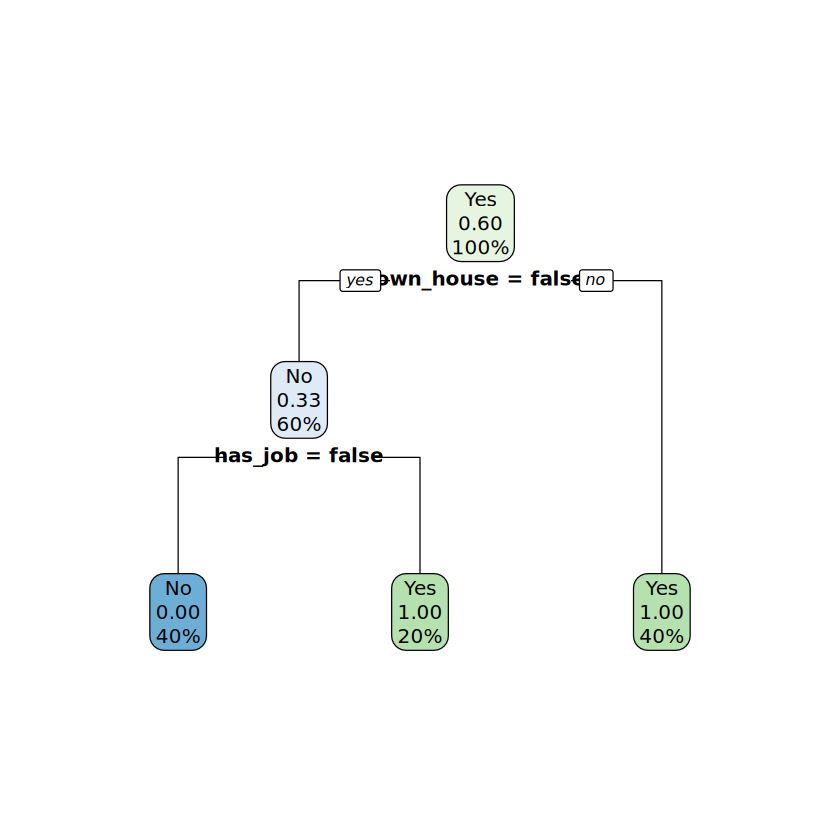

In [6]:
#CART
library(rpart)
library(rpart.plot)
tree <- rpart(class ~ ., method='class', data=loan_data, 
              control=rpart.control(minsplit=2, minbucket=1, cp=0.001))
rpart.plot(tree)

In [7]:
summary(tree)

Call:
rpart(formula = class ~ ., data = loan_data, method = "class", 
    control = rpart.control(minsplit = 2, minbucket = 1, cp = 0.001))
  n= 15 

     CP nsplit rel error xerror      xstd
1 0.500      0         1    1.0 0.3162278
2 0.001      2         0    0.5 0.2581989

Variable importance
      has_job     own_house credit_rating           age 
           35            28            21            16 

Node number 1: 15 observations,    complexity param=0.5
  predicted class=Yes  expected loss=0.4  P(node) =1
    class counts:     6     9
   probabilities: 0.400 0.600 
  left son=2 (9 obs) right son=3 (6 obs)
  Primary splits:
      own_house     splits as  LR,  improve=3.2, (0 missing)
      has_job       splits as  LR,  improve=2.4, (0 missing)
      credit_rating splits as  RLR, improve=2.4, (0 missing)
      age           splits as  LRL, improve=0.6, (0 missing)
  Surrogate splits:
      credit_rating splits as  RLL, agree=0.733, adj=0.333, (0 split)
      age           split

In [25]:
#棒球联盟数据集
library(ISLR)
str(Hitters)

'data.frame':	322 obs. of  20 variables:
 $ AtBat    : int  293 315 479 496 321 594 185 298 323 401 ...
 $ Hits     : int  66 81 130 141 87 169 37 73 81 92 ...
 $ HmRun    : int  1 7 18 20 10 4 1 0 6 17 ...
 $ Runs     : int  30 24 66 65 39 74 23 24 26 49 ...
 $ RBI      : int  29 38 72 78 42 51 8 24 32 66 ...
 $ Walks    : int  14 39 76 37 30 35 21 7 8 65 ...
 $ Years    : int  1 14 3 11 2 11 2 3 2 13 ...
 $ CAtBat   : int  293 3449 1624 5628 396 4408 214 509 341 5206 ...
 $ CHits    : int  66 835 457 1575 101 1133 42 108 86 1332 ...
 $ CHmRun   : int  1 69 63 225 12 19 1 0 6 253 ...
 $ CRuns    : int  30 321 224 828 48 501 30 41 32 784 ...
 $ CRBI     : int  29 414 266 838 46 336 9 37 34 890 ...
 $ CWalks   : int  14 375 263 354 33 194 24 12 8 866 ...
 $ League   : Factor w/ 2 levels "A","N": 1 2 1 2 2 1 2 1 2 1 ...
 $ Division : Factor w/ 2 levels "E","W": 1 2 2 1 1 2 1 2 2 1 ...
 $ PutOuts  : int  446 632 880 200 805 282 76 121 143 0 ...
 $ Assists  : int  33 43 82 11 40 421 127 28

In [26]:
sum(is.na(Hitters))

[1] 59

In [27]:
Hitters <- na.omit(Hitters)
str(Hitters)

'data.frame':	263 obs. of  20 variables:
 $ AtBat    : int  315 479 496 321 594 185 298 323 401 574 ...
 $ Hits     : int  81 130 141 87 169 37 73 81 92 159 ...
 $ HmRun    : int  7 18 20 10 4 1 0 6 17 21 ...
 $ Runs     : int  24 66 65 39 74 23 24 26 49 107 ...
 $ RBI      : int  38 72 78 42 51 8 24 32 66 75 ...
 $ Walks    : int  39 76 37 30 35 21 7 8 65 59 ...
 $ Years    : int  14 3 11 2 11 2 3 2 13 10 ...
 $ CAtBat   : int  3449 1624 5628 396 4408 214 509 341 5206 4631 ...
 $ CHits    : int  835 457 1575 101 1133 42 108 86 1332 1300 ...
 $ CHmRun   : int  69 63 225 12 19 1 0 6 253 90 ...
 $ CRuns    : int  321 224 828 48 501 30 41 32 784 702 ...
 $ CRBI     : int  414 266 838 46 336 9 37 34 890 504 ...
 $ CWalks   : int  375 263 354 33 194 24 12 8 866 488 ...
 $ League   : Factor w/ 2 levels "A","N": 2 1 2 2 1 2 1 2 1 1 ...
 $ Division : Factor w/ 2 levels "E","W": 2 2 1 1 2 1 2 2 1 1 ...
 $ PutOuts  : int  632 880 200 805 282 76 121 143 0 238 ...
 $ Assists  : int  43 82 11 40 42

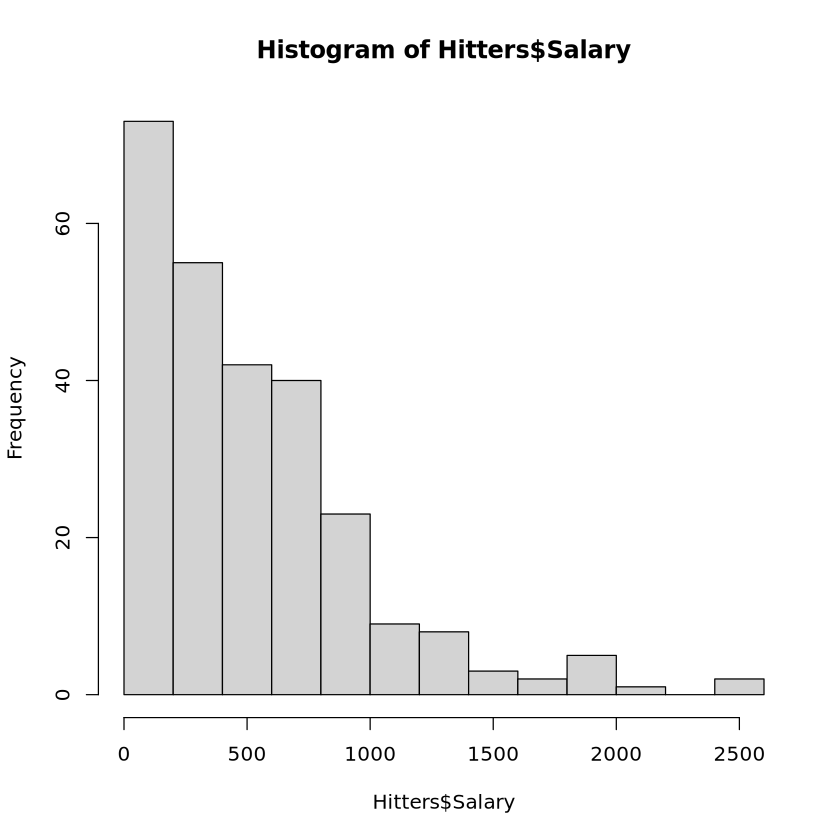

In [28]:
hist(Hitters$Salary)

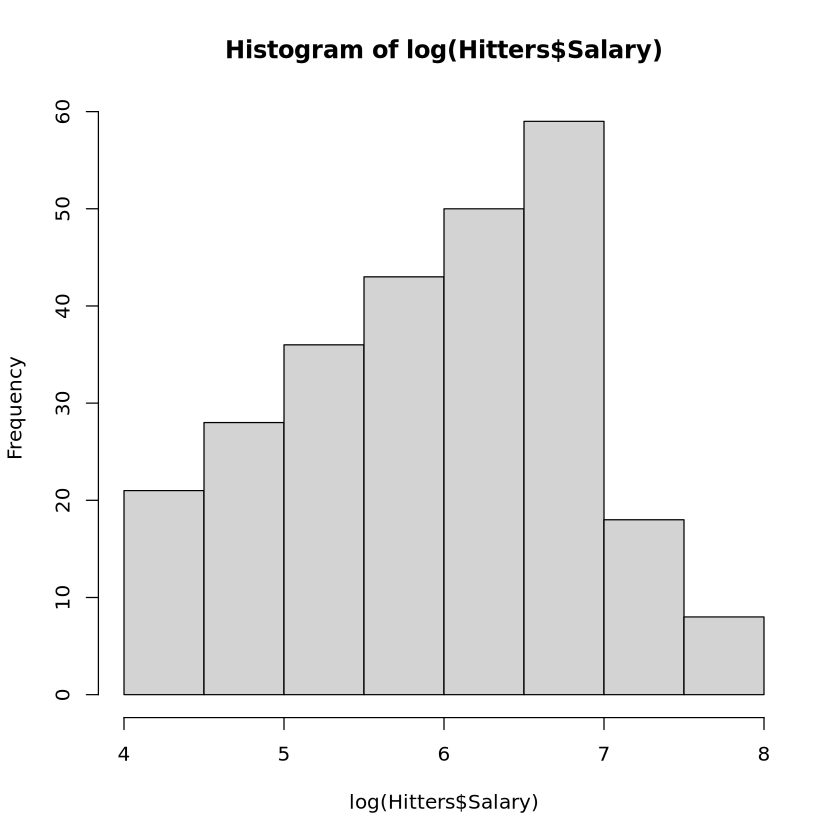

In [29]:
hist(log(Hitters$Salary))

In [30]:
summary(Hitters$Salary)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   67.5   190.0   425.0   535.9   750.0  2460.0 

In [31]:
summary(log(Hitters$Salary))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  4.212   5.247   6.052   5.927   6.620   7.808 

In [32]:
library(tree)
treefit <- tree(log(Salary) ~ Years + Hits, data=Hitters)
treefit

node), split, n, deviance, yval
      * denotes terminal node

 1) root 263 207.200 5.927  
   2) Years < 4.5 90  42.350 5.107  
     4) Years < 3.5 62  23.010 4.892  
       8) Hits < 114 43  17.150 4.727  
        16) Hits < 40.5 5  10.400 5.511 *
        17) Hits > 40.5 38   3.280 4.624 *
       9) Hits > 114 19   2.069 5.264 *
     5) Years > 3.5 28  10.130 5.583 *
   3) Years > 4.5 173  72.710 6.354  
     6) Hits < 117.5 90  28.090 5.998  
      12) Years < 6.5 26   7.238 5.689 *
      13) Years > 6.5 64  17.350 6.124  
        26) Hits < 50.5 12   2.689 5.730 *
        27) Hits > 50.5 52  12.370 6.215 *
     7) Hits > 117.5 83  20.880 6.740 *

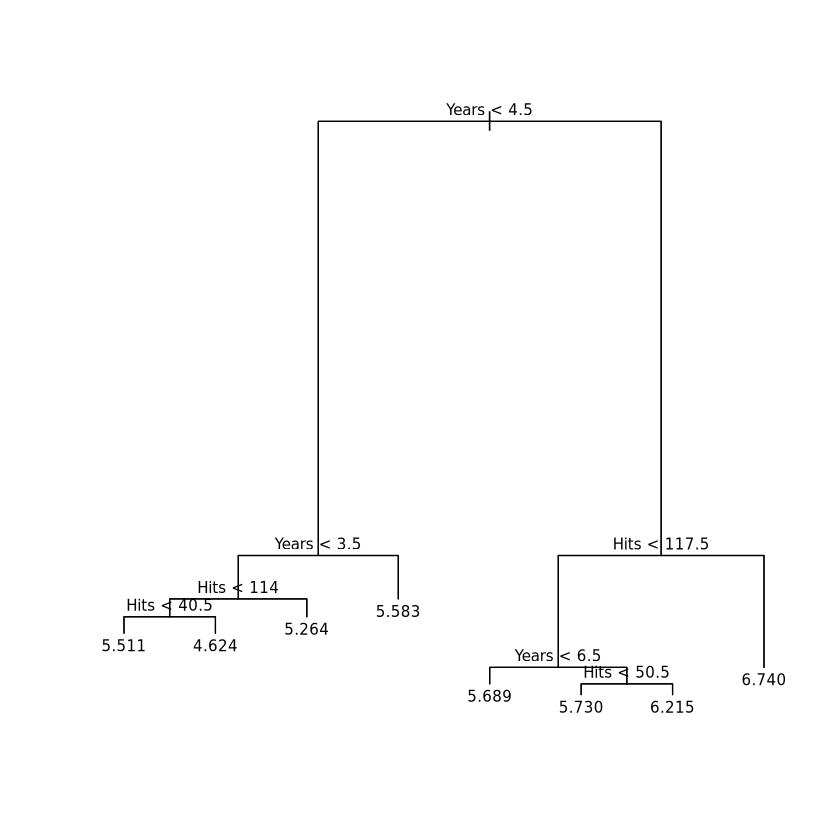

In [33]:
plot(treefit)
text(treefit, cex=0.75)

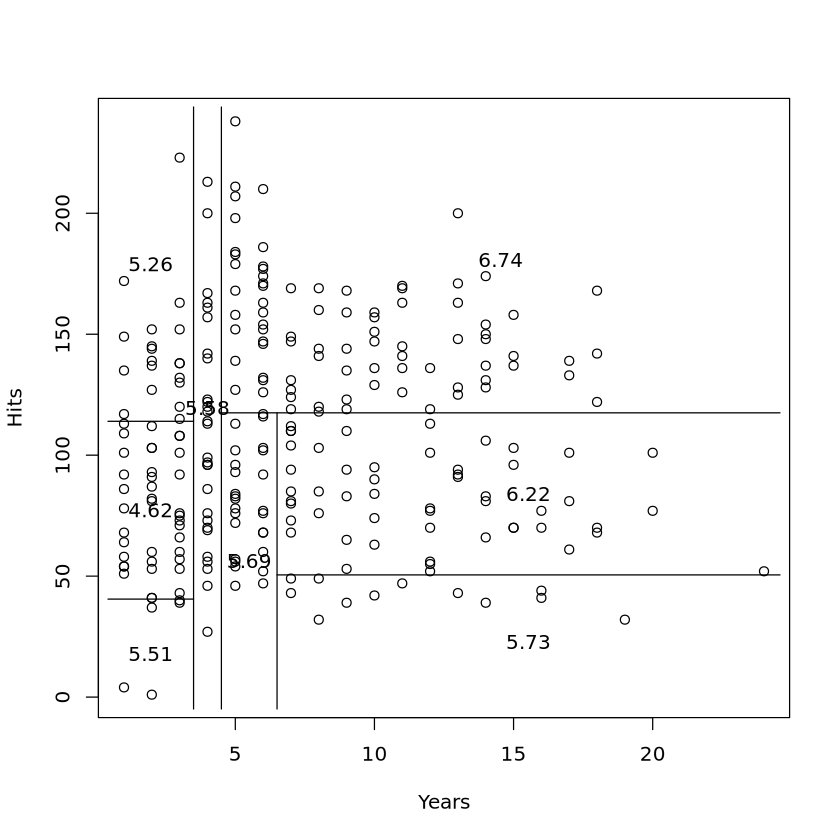

In [34]:
plot(Hitters$Years, Hitters$Hits, xlab="Years", ylab="Hits")
partition.tree(treefit, add=TRUE)

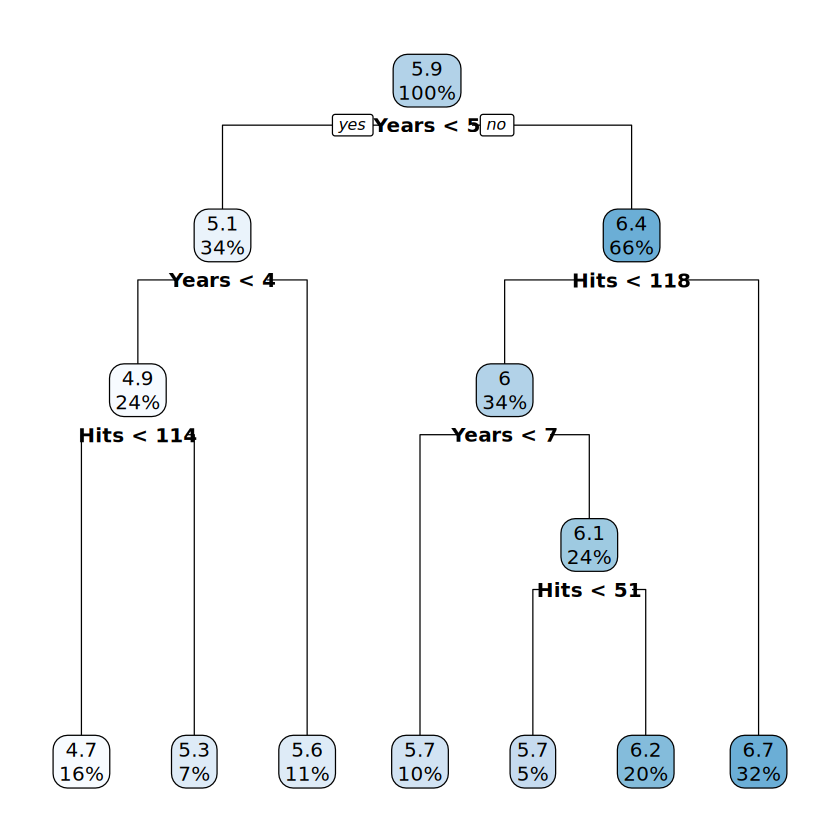

In [35]:
tfit <- rpart(log(Salary) ~ Years + Hits, data=Hitters)
rpart.plot(tfit)